# FLASH Soil Saturation Diagnostics
## Prototype Analysis Notebook (Single Case)
------

### Notebook Setup

In [14]:
# Let's import the needed libraries
import    urllib.request# helps us download files from the internet
import    gzip          # helps us unzip .gz files
import    tempfile      # creates a temporary file that will disappear later
import    xarray as xr  # the best tool to read weather raster files
from datetime import datetime # handles date and time
from datetime import timedelta # Manipulating time
import numpy as np               # for arrays and math (np = nickname)
import matplotlib.pyplot as plt  # main plotting tool (plt = nickname)
import cartopy.crs as ccrs       # map projections
import cartopy.feature as cfeature  # add states, coastlines, etc.
import numpy.ma as ma            # mask/hide bad values
from metpy.plots import ctables  # official radar colors
import matplotlib.colors as mcolors
import os
import requests

# Core scientific Python stack
import numpy as np
import pandas as pd
import rasterio
import rioxarray as rxr
from rasterio.enums import Resampling

# NLDAS Access
import earthaccess

# ML tools
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Image / segmentation utilities
from scipy import ndimage

### Step 1 - Define the Analysis Case
This section has three steps:

- Parse a string → datetime object
- Extract components from the datetime object
- Format those components back into strings for URLs, paths, or filenames

“We parse date‑time strings into Python’s datetime objects so we can extract and format year, month, day, and time components reliably when constructing file paths and URLs.”

In [15]:
# ===============================
# USER-DEFINED CONFIGURATION
# ===============================

case_date = "2024-06-22"
case_time = "19:00"  # UTC

# Simple bounding box (Iowa region)
lon_min, lon_max = -130, -60 #-97.5, -90.0
lat_min, lat_max = 30,50 #40.0, 45

# Parse it into a datetime object
case_dt = datetime.strptime(case_date + " " + case_time, "%Y-%m-%d %H:%M")

# Accessing Date Components Directly
year  = case_dt.year
month = case_dt.month
day   = case_dt.day
hour  = case_dt.hour
minute = case_dt.minute


In [16]:
print(case_date + " " + case_time)

2024-06-22 19:00


### Step 2 — Download and Load Data
#### FLASH data from ISU Mesonet Archive (CREST Soil Saturation & Unit Q)

In [17]:
# A function that downloads FLASH data given a product name and a date
def downloadFLASH(flash_product,flash_date):
    year_str  = flash_date.strftime("%Y")   # "2019"
    month_str = flash_date.strftime("%m")   # "05"
    day_str   = flash_date.strftime("%d")   # "23"
    hour_str  = flash_date.strftime("%H")   # "12"
    minute_str = flash_date.strftime("%M")  # "00"
    
    url = (f"https://mtarchive.geol.iastate.edu/"
           f"{year_str}/{month_str}/{day_str}/mrms/ncep/FLASH/{flash_product}/"
           f"{flash_product}_00.00_{year_str}{month_str}{day_str}-{hour_str}0000.grib2.gz")

    response = urllib.request.urlopen(url)
    compressed_data = response.read()
    
    print(url)
    print(f"   → Got the file! Size: {len(compressed_data):,} bytes (compressed)")
    
    print("Starting to unzip and load the radar file...")
    
    # We create a temporary file on your computer.
    # This file will hold the unzipped version.
    with tempfile.NamedTemporaryFile(suffix=".grib2") as temp_file:
    
        # ────────────────
        # Part A: Unzip (decompress) the file we downloaded
        # ────────────────
        unzipped_data = gzip.decompress(compressed_data)
        
        print(f"   → Unzipped! New size = {len(unzipped_data):,} bytes")
    
        # Write the unzipped bytes into our temporary file
        temp_file.write(unzipped_data)
        
        # flush() = "make sure everything is really written to disk now"
        # (very important before reading the file)
        temp_file.flush()
        
        print(f"   → Unzipped file saved temporarily at: {temp_file.name}")
    
        # ────────────────
        # Part B: Read the weather data with xarray 
        # ────────────────
        data_in = xr.load_dataarray(
            temp_file.name,             # where the file is
            engine='cfgrib',            # special tool for weather GRIB files
            decode_timedelta=True       # helps with time information
        )

    # Process the downloaded data
    lons = data_in.longitude           # east-west positions (longitudes)
    lats = data_in.latitude            # north-south positions (latitudes)
    refl = data_in.values              # FLASH variable in each grid cell — the main data
    
    flash_layer = data_in.assign_coords(
        longitude=(((data_in.longitude + 180) % 360) - 180)
    ).sortby("longitude")
    
    flash_layer = flash_layer.rename({"longitude": "x", "latitude": "y"})
    flash_layer = flash_layer.rio.set_spatial_dims("x", "y")
    flash_layer = flash_layer.rio.write_crs("EPSG:4326")
    flash_layer = flash_layer.rio.write_nodata(-9999)
    flash_layer = flash_layer.rio.write_transform()

    return flash_layer

#### Download Specific Products

In [18]:
## FLASH UNIT Q Layer
flas_uq_da = downloadFLASH("CREST_MAXUNITSTREAMFLOW",case_dt)

## FLASH SOILSAT Layer
flas_soil_da = downloadFLASH("CREST_MAXSOILSAT",case_dt)

https://mtarchive.geol.iastate.edu/2024/06/22/mrms/ncep/FLASH/CREST_MAXUNITSTREAMFLOW/CREST_MAXUNITSTREAMFLOW_00.00_20240622-190000.grib2.gz
   → Got the file! Size: 2,018,453 bytes (compressed)
Starting to unzip and load the radar file...
   → Unzipped! New size = 2,086,663 bytes
   → Unzipped file saved temporarily at: /tmp/tmpg60fpt_j.grib2
https://mtarchive.geol.iastate.edu/2024/06/22/mrms/ncep/FLASH/CREST_MAXSOILSAT/CREST_MAXSOILSAT_00.00_20240622-190000.grib2.gz
   → Got the file! Size: 3,848,678 bytes (compressed)
Starting to unzip and load the radar file...
   → Unzipped! New size = 3,928,842 bytes
   → Unzipped file saved temporarily at: /tmp/tmp4uiwpyv8.grib2


#### NLDAS Layers
 Download outputs from the NOAH-MP Land Surface model - More information at https://ldas.gsfc.nasa.gov/nldas

In [19]:
# NLDAS

# Login (only once per machine)
earthaccess.login(persist=True)

# Download ONE real file
results = earthaccess.search_data(
    short_name="NLDAS_NOAH0125_H",
    version="2.0",
    temporal=case_dt.strftime("%Y-%m-%d %H:%M"), # ("2024-12-25 10:00", "2024-05-27 20:00"), #case_dt.strftime("%Y-%m-%d %H:%M"), # 
    count=1
)

print(f"Found {len(results)} granule")

files = earthaccess.download(results, "./nldas_data/")
local_file = files[0]
# print("File:", local_file)

# Open with xarray
ds_nldas = xr.open_dataset(local_file, engine="netcdf4")
# print(ds_nldas.variables)

# def dowloadNLDAS():
#     #https://hydro1.gesdisc.eosdis.nasa.gov/data/NLDAS/NLDAS_NOAH0125_H.2.0/2019/022/NLDAS_NOAH0125_H.A20190122.1500.020.nc

Found 1 granule


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
# Map NLDAS Soil layers onto FLASH Soil Saturation Definition

# Load in the Depth-to-Bedrock layer used in FLASH to determine Maximum Soil Depth (cm)
with rasterio.open("RockDepth_1km_mrms_grid.tif") as src:
    soil_depth = src.read(1)        # NumPy array
    transform = src.transform
    crs = src.crs
    nodata = src.nodata

# Load in the Effective Porosity layer used in FLASH to determine Maximum Water Capacity
with rasterio.open("Effective_Porosity_FLASH_MRMS_1km.tif") as src:
    soil_eff_porosity = src.read(1)        # NumPy array
    # transform = src.transform
    # crs = src.crs
    # nodata = src.nodata

# Resample and Reproject NLDAS to FLASH grid
# soil100cm_nldas = ds_nldas["SMAvail_0_200cm"]

# soil100cm_nldas = ds_nldas["SoilM_0_200cm"]

def nldas2FLASH(nldas_layer,flash_layer):
    nldas_layer = nldas_layer.rename({"lon": "x", "lat": "y"})

    # Activate rioxarray
    nldas_layer = nldas_layer.rio.set_spatial_dims(x_dim="x", y_dim="y")
    nldas_layer = nldas_layer.rio.write_crs("EPSG:4326")
    nldas_layer = nldas_layer.rio.write_transform()
    
    # Reproject / resample
    warped_nldas_layer = nldas_layer.rio.reproject(
        "EPSG:4326",
        resolution=0.01,
        resampling=Resampling.bilinear
        
    )
    
    # Get bounding box of reference raster
    minx, miny, maxx, maxy = flash_layer.rio.bounds()
    
    nldas_mrmsgrid = warped_nldas_layer.rio.reproject_match(flash_layer)

    return nldas_mrmsgrid

# Transform NLDAS layers to MRMS-FLASH grid conventions
# 0 - 200 cm
soil200cm_nldas_mrmsgrid = nldas2FLASH(ds_nldas["SoilM_0_200cm"],flas_uq_da)
# 0 - 100 cm
soil100cm_nldas_mrmsgrid = nldas2FLASH(ds_nldas["SoilM_0_100cm"],flas_uq_da)

# Combine both NLDAS soil layers considering soil depth
# Initialize the combined layer with the 100-cm layer. All pixels with soil depth > 200 cm get the 0-200cm values
soil_nldas_mrmsgrid = xr.where(
    soil_depth > 200,
    soil200cm_nldas_mrmsgrid.isel(time=0),
    soil100cm_nldas_mrmsgrid.isel(time=0))

# Pixels with soil depth between 100 and 200 cm get the weighted average
mask_mid = (soil_depth > 100) & (soil_depth <= 200)
soil_interp = soil100cm_nldas_mrmsgrid.isel(time=0) + (soil_depth - 100) * (soil200cm_nldas_mrmsgrid.isel(time=0) - soil100cm_nldas_mrmsgrid.isel(time=0)) / 100.0
soil_nldas_mrmsgrid = xr.where(
    mask_mid,
    soil_interp,
    soil_nldas_mrmsgrid
)

# Water density
rho_water = 1000 # kg m-3

# Convert Soil moisture content kg m-2 to an estimate of Soil Saturation (%)
theta = soil_nldas_mrmsgrid / (rho_water * soil_depth * 0.01) # theta = Volumetric soil moisture
nldas_soil_flash_saturation = (theta / soil_eff_porosity) * 100


#### Local Storm Reports (LSRs)
Download from ISU Mesonet App

In [28]:
# This is the web address (API) we will ask for data
base_url = 'https://mesonet.agron.iastate.edu/cgi-bin/request/gis/lsr.py'

# We will look for LSRs using a -6 hours + 6 hours window of the case study date
start_dt = case_dt - timedelta(hours=6)
end_dt = case_dt + timedelta(hours=6)

# These are our choices (like filling out a form)
params = {
    # 'state': 'IA',                   # Only Iowa
    'sts': start_dt.strftime('%Y-%m-%dT%H:%M:%SZ'), #'2024-05-01T00:00:00Z',   # Start time (change these dates!)
    'ets': end_dt.strftime('%Y-%m-%dT%H:%M:%SZ'), #'2024-07-07T23:59:59Z',   # End time
    'fmt': 'csv'                     # We want CSV format
}

# Choose a name for our file
file_name = 'lsr_list.csv'
file_path = os.path.join(os.getcwd(), file_name)   # full path on your computer

# print(f"Trying to download data for {date_range} ...")

# Ask the website (make the request)
response = requests.get(base_url, params=params, timeout=15)

# Did it work?
if response.status_code == 200:
    # Get the text content
    text = response.text.strip()
    
    # Check if they said "no data"
    if len(text) < 1 or "NO DATA" in text.upper():
        print("→ No storm reports found for these dates.")
    else:
        # Save it to a file
        with open(file_path, 'w', encoding='utf-8') as file:
            file.write(text)
        print(f"→ Success! File saved here: {file_path}")
        print(f"   File size: {os.path.getsize(file_path) / 1024:.1f} KB")
else:
    print(f"→ Error! Status code: {response.status_code}")

# Check if the file really exists
if not os.path.exists(file_path):
    print("No file found. Did Step 2 work?")
else:
    print(f"Reading file: {file_name}\n")
    
    # Read the CSV into a table (called DataFrame)
    df = pd.read_csv(
        file_path,
        header=0,               # first row = column names
        on_bad_lines='skip',    # skip bad lines if any
        encoding='utf-8'
    )
    
# Filter LSRs to only show FLASH FLOODS
if 'df' not in globals() or df.empty:
    print("No data loaded yet.")
else:
    # Change this line to try different types!
    wanted_type = 'FLASH FLOOD'          # ← you can change this

    # Filter: keep only rows where TYPETEXT matches wanted_type
    filtered = df[df['TYPETEXT'] == wanted_type]

    print(f"Showing reports where TYPETEXT = '{wanted_type}'")
    print(f"Found {len(filtered)} matching reports\n")

    if len(filtered) > 0:
        display(filtered[['VALID2', 'CITY', 'COUNTY', 'TYPETEXT', 'MAG']].head(8))
    else:
        print("→ No reports of this type in the selected time period.")

→ Success! File saved here: /home/hvergaraarrieta/Data_Science/data_analytics/lsr_list.csv
   File size: 90.3 KB
Reading file: lsr_list.csv

Showing reports where TYPETEXT = 'FLASH FLOOD'
Found 40 matching reports



,VALID2,CITY,COUNTY,TYPETEXT,MAG
161,2024/06/22 14:51,1 N Hawkeye,Fayette,FLASH FLOOD,NaN
274,2024/06/22 20:05,11 WSW Meeker,Rio Blanco,FLASH FLOOD,NaN
313,2024/06/22 21:06,5 NE Tucson,Pima,FLASH FLOOD,NaN
316,2024/06/22 21:10,2 ENE Hollandale,Freeborn,FLASH FLOOD,NaN
317,2024/06/22 21:10,3 W Alden,Freeborn,FLASH FLOOD,NaN
323,2024/06/22 21:16,3 NNE Tucson,Pima,FLASH FLOOD,NaN
337,2024/06/22 21:40,4 NNW Tucson,Pima,FLASH FLOOD,NaN
338,2024/06/22 21:41,5 NW Tucson,Pima,FLASH FLOOD,NaN


#### Create Figure

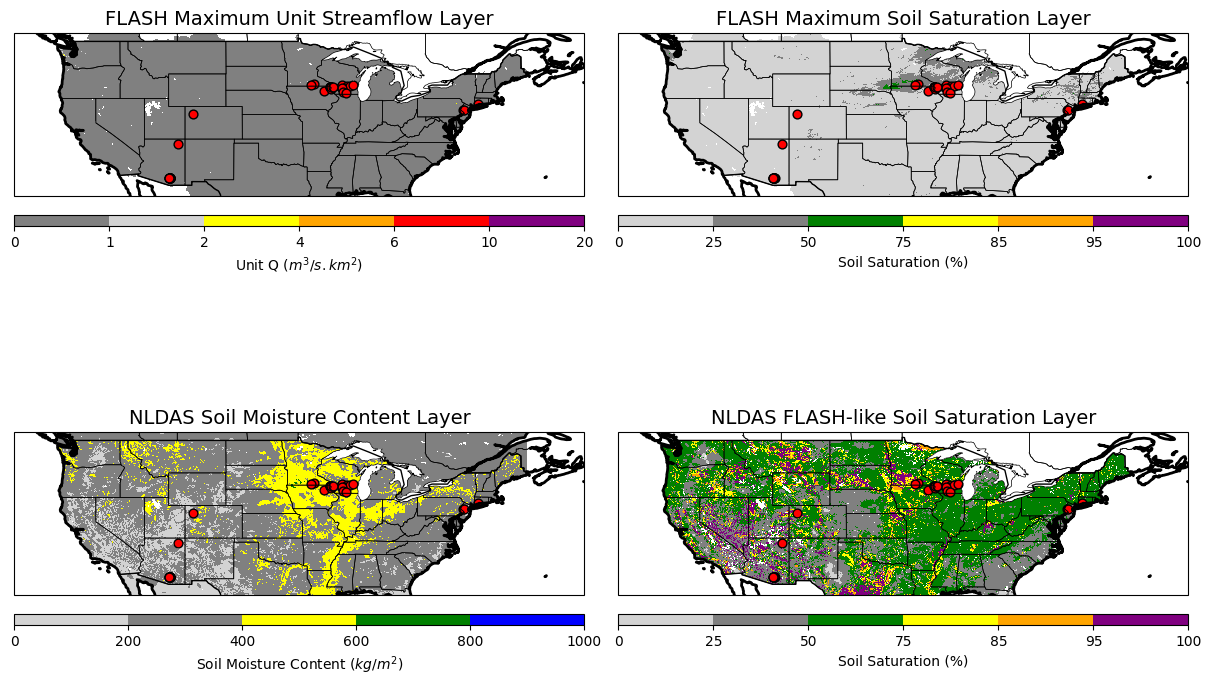

In [30]:
# Create a 4-panel figure
fig, axs = plt.subplots(
    2, 2, figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Define general graphic settings
map_extent_for_graph = [lon_min, lon_max, lat_min, lat_max]

# FLASH PLOTTING FUNCTION
def plot_FLASH(c_ax,map_extent,flash_product,dataArray,reports,sub_title):
    # Color - 
    all_products = {'unitq':{'label':r'Unit Q ($m^3/s.km^2$)', 'graphpars':{'clims':[0,20], 'clevs':[0,1,2,4,6,10,20], 'colors':['grey', 'lightgrey', 'yellow', 'orange', 'red', 'purple']}},
                'soilsat':{'label':r'Soil Saturation (%)', 'graphpars':{'clims':[0,100], 'clevs':[0,25,50,75,85,95,100], 'colors':['lightgrey', 'grey', 'green', 'yellow', 'orange', 'purple']}},
                   'nldas':{'label':r'Soil Moisture Content ($kg/m^2$)', 'graphpars':{'clims':[0,1000], 'clevs':[0,200,400,600,800,1000], 'colors':['lightgrey', 'grey', 'yellow', 'green', 'blue']}}}
    # FLASH UNIT Q
    ax = axs[c_ax[0], c_ax[1]]

    ax.set_extent(map_extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=2)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.add_feature(cfeature.STATES, linewidth=0.5)

    clevs = all_products[flash_product]['graphpars']['clevs']
    colors = all_products[flash_product]['graphpars']['colors']
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(clevs, cmap.N)

    dataArray = dataArray.where(dataArray >= 0)
    
    # Create colored mesh
    mesh = dataArray.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.scatter(
        reports.LON,
        reports.LAT,
        color="red",
        s=40,
        marker="o",
        edgecolor="black",
        label="Local Storm Reports",
        transform=ccrs.PlateCarree()
    )

    # Add colorbar (legend) to explain colors
    cb = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
    cb.set_label(all_products[flash_product]['label'])  # label explains what the numbers mean

    # Add title at the top
    ax.set_title(sub_title, fontsize=14)

# FLASH UNIT Q
current_ax = [0,0]
this_flash_product = 'unitq'
this_dataArray = flas_uq_da
plot_FLASH(current_ax,map_extent_for_graph,this_flash_product,this_dataArray, filtered, 'FLASH Maximum Unit Streamflow Layer')

# FLASH SOIL SATURATION
current_ax = [0,1]
this_flash_product = 'soilsat'
this_dataArray = flas_soil_da
plot_FLASH(current_ax,map_extent_for_graph,this_flash_product,this_dataArray,  filtered, 'FLASH Maximum Soil Saturation Layer')

# NLDAS SOIL MOISTURE
current_ax = [1,0]
this_flash_product = 'nldas'
this_dataArray = soil_nldas_mrmsgrid
plot_FLASH(current_ax,map_extent_for_graph,this_flash_product,this_dataArray,  filtered, 'NLDAS Soil Moisture Content Layer')

# NLDAS SOIL SATURATION (FLASH Like)
current_ax = [1,1]
this_flash_product = 'soilsat'
this_dataArray = nldas_soil_flash_saturation
plot_FLASH(current_ax,map_extent_for_graph,this_flash_product,this_dataArray,  filtered, 'NLDAS FLASH-like Soil Saturation Layer')

# Save as Figure
# plt.savefig('FLASH_Soil_Analysis_for_' + case_dt.strftime('%Y%m%d%H%M') + '.png', dpi=150)

# # Show figure
plt.show()